# 02 · eda

explore the universe + build the label (fund vs its category median over the next 5 days).
run notebook 01 first. ~2k funds so we look at things by category, not one line per fund.

## tl;dr - what the data says

- **~1480 us etfs, 10y, ~33 categories** after dropping leveraged/inverse, broken series (bad ticks),
  and delisted/dead funds (financedatabase still lists ~380 etfs that stopped trading, e.g. ACTV).
- **coverage:** half the funds have the full 10y, a quarter have < ~6.5y. newer funds are just NaN
  before they launched (the panel is ~17% NaN - all pre-launch, expected).
- **label ~51% neutral / 24% over / 24% under** at the 50 bps threshold - but that split is *totally
  different by asset class*: **bonds ~77% neutral** (they barely leave their peers), **sector-equity
  ~25% neutral** (they swing). the model is really solving a different problem per group.
- **balance moves with the market:** neutral drops to ~44% in volatile years (2020, 2022), ~58% in calm
  ones (2017, 2019).
- **signal is nonlinear** (see nb03 decile plots): no feature separates direction *linearly* (best ~0.04
  std), but bucketed, momentum is V-shaped (both tails outperform) and vol/rsi are monotonic. so this
  wants **tree/boosting models, not plain logistic regression**.
- **⚠️ leakage risk:** the label is a forward 5-day return measured daily, so consecutive days overlap
  (lag-1 autocorr ~0.75). the modeling side must use purged/embargoed walk-forward CV or scores will lie.

In [1]:
import yaml, pathlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
pd.set_option('display.width', 200, 'display.max_columns', 30)

ROOT = pathlib.Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
import common
cfg = yaml.safe_load(open(ROOT / 'config.yaml', encoding='utf-8'))
RAW  = ROOT / cfg['paths']['raw']
prices   = pd.read_parquet(RAW / 'prices.parquet')
metadata = pd.read_parquet(RAW / 'metadata.parquet')
prices.index.name = 'date'; prices.columns.name = 'ticker'

# drop leveraged/inverse etfs and broken price series before analysis
bad = pd.Series(False, index=metadata.index)
if cfg.get('exclude_leveraged') and 'is_leveraged' in metadata.columns:
    bad |= metadata['is_leveraged'].fillna(False)
if 'bad_ticks' in metadata.columns:
    bad |= metadata['bad_ticks'].fillna(False)
if cfg.get('exclude_delisted') and 'is_delisted' in metadata.columns:
    bad |= metadata['is_delisted'].fillna(False)
prices = prices.drop(columns=[c for c in metadata.index[bad] if c in prices.columns])
print('dropped', int(bad.sum()), 'funds (leveraged + bad ticks + delisted) |', prices.shape[1], 'left,', metadata['category'].nunique(), 'categories')

dropped 520 funds (leveraged + bad ticks + delisted) | 1455 left, 40 categories


### heads up: the early years are empty on purpose

with a 10y window most etfs are NaN before they launched (~2015+), so the *top* of the price
panel looks all-null. thats expected, not a bug. the labels we save at the end drop those rows.
here's a clean recent slice so you can see real data:

In [2]:
naf = prices.isna().mean().mean() * 100
print(f'{naf:.0f}% of the panel is NaN - all pre-launch rows. per-fund history below in \"history coverage\".')
prices.tail(4).iloc[:, :8]

10% of the panel is NaN - all pre-launch rows. per-fund history below in "history coverage".


ticker,AAA,AAAU,AADR,AAXJ,ABCS,ABEQ,ACES,ACVF
date,,,,,,,,
2026-07-07,25.031000,40.570000,83.000000,114.250000,34.187000,37.768002,33.279999,53.779999
2026-07-08,25.010000,40.240002,83.089996,115.209999,33.716000,37.273998,33.259998,53.673000
2026-07-09,25.000000,40.639999,84.150002,116.290001,34.039001,37.270000,33.700001,54.132000
2026-07-10,24.950001,40.500000,84.190002,116.220001,34.161999,37.419998,33.270000,54.430000


## what got cleaned out

before any analysis we drop three kinds of junk (all configurable in `config.yaml`). the biggest
chunk is **delisted funds** - dead etfs financedatabase still lists whose price just stops (e.g. ACTV
delisted oct-2025). turning `exclude_delisted` off keeps them (less survivorship bias, messier data).

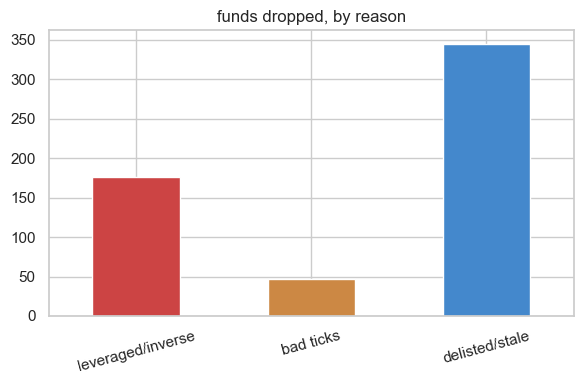

leveraged/inverse    176
bad ticks             47
delisted/stale       345
dtype: int64

In [3]:
raw_md = pd.read_parquet(RAW / 'metadata.parquet')
reasons = pd.Series({
    'leveraged/inverse': int(raw_md.get('is_leveraged', pd.Series(dtype=bool)).sum()),
    'bad ticks':         int(raw_md.get('bad_ticks', pd.Series(dtype=bool)).sum()),
    'delisted/stale':    int(raw_md.get('is_delisted', pd.Series(dtype=bool)).sum()),
})
ax = reasons.plot.bar(figsize=(6, 4), color=['#c44','#c84','#48c'])
ax.set_title('funds dropped, by reason'); ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()
reasons

## universe overview

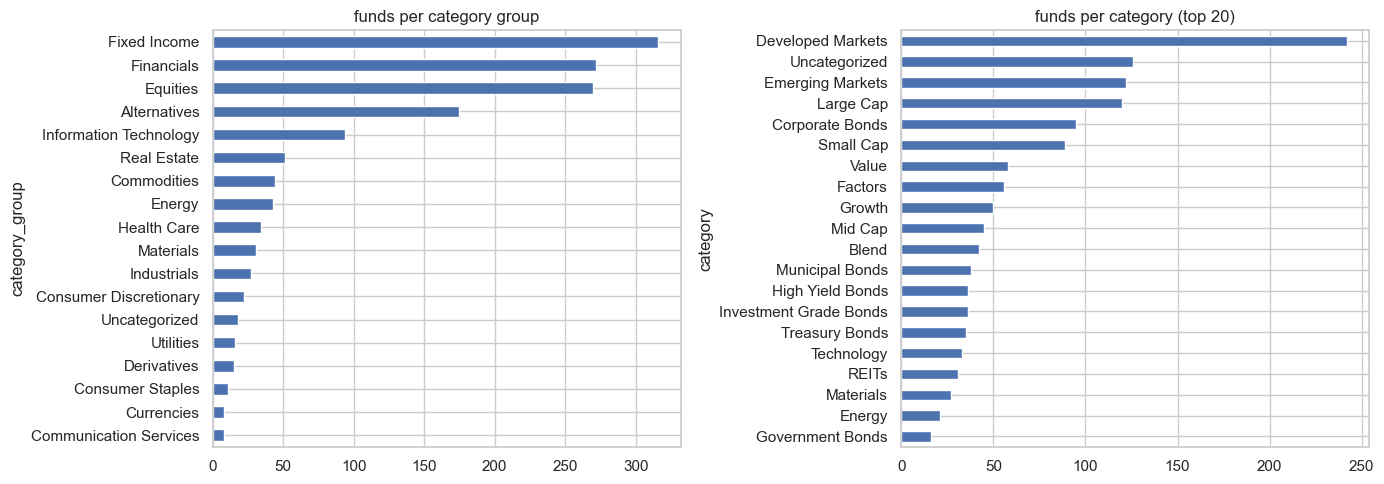

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
metadata['category_group'].reindex(prices.columns).value_counts().plot.barh(ax=ax[0]); ax[0].invert_yaxis(); ax[0].set_title('funds per category group')
metadata['category'].reindex(prices.columns).value_counts().head(20).plot.barh(ax=ax[1]); ax[1].invert_yaxis(); ax[1].set_title('funds per category (top 20)')
plt.tight_layout(); plt.show()

### how the universe grew + what's in it

active funds climb as etfs launch (and dip where they delist). launches peaked mid-cycle; almost
everything is usd.

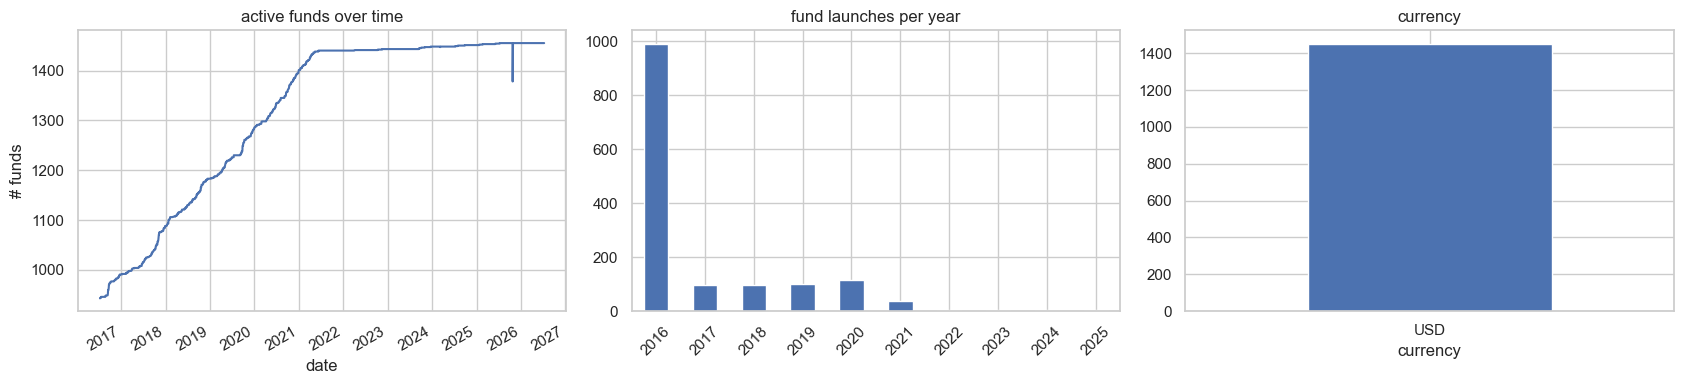

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
prices.notna().sum(axis=1).plot(ax=ax[0]); ax[0].set_title('active funds over time'); ax[0].set_ylabel('# funds')
launch = prices.apply(lambda s: s.first_valid_index()).dropna()
launch.dt.year.value_counts().sort_index().plot.bar(ax=ax[1]); ax[1].set_title('fund launches per year'); ax[1].tick_params(axis='x', rotation=45)
metadata['currency'].reindex(prices.columns).value_counts().plot.bar(ax=ax[2]); ax[2].set_title('currency'); ax[2].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## history coverage

how much history does each fund actually have? most etfs are way younger than our 10y window,
so they're just empty (NaN) before they launched. thats why the raw price panel / early label
rows look 'all null' - its not a bug, those funds didnt exist yet. we drop the empty rows when
we save the labels below.

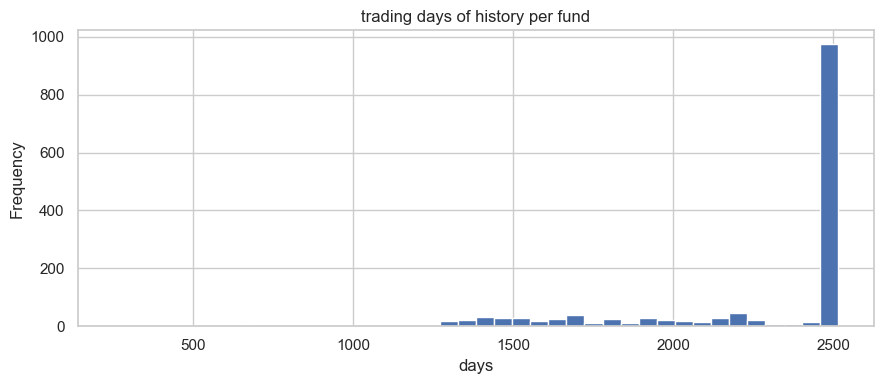

count    1455.0
mean     2273.0
std       408.0
min       252.0
25%      2132.0
50%      2514.0
75%      2514.0
max      2514.0
dtype: float64

In [6]:
cover = prices.notna().sum()
ax = cover.plot.hist(bins=40, figsize=(9, 4)); ax.set_title('trading days of history per fund'); ax.set_xlabel('days')
plt.tight_layout(); plt.show()
cover.describe().round(0)

## prices & returns

what the funds actually did. composites = cross-sectional mean daily return per category group,
cumulated into a $1 index.

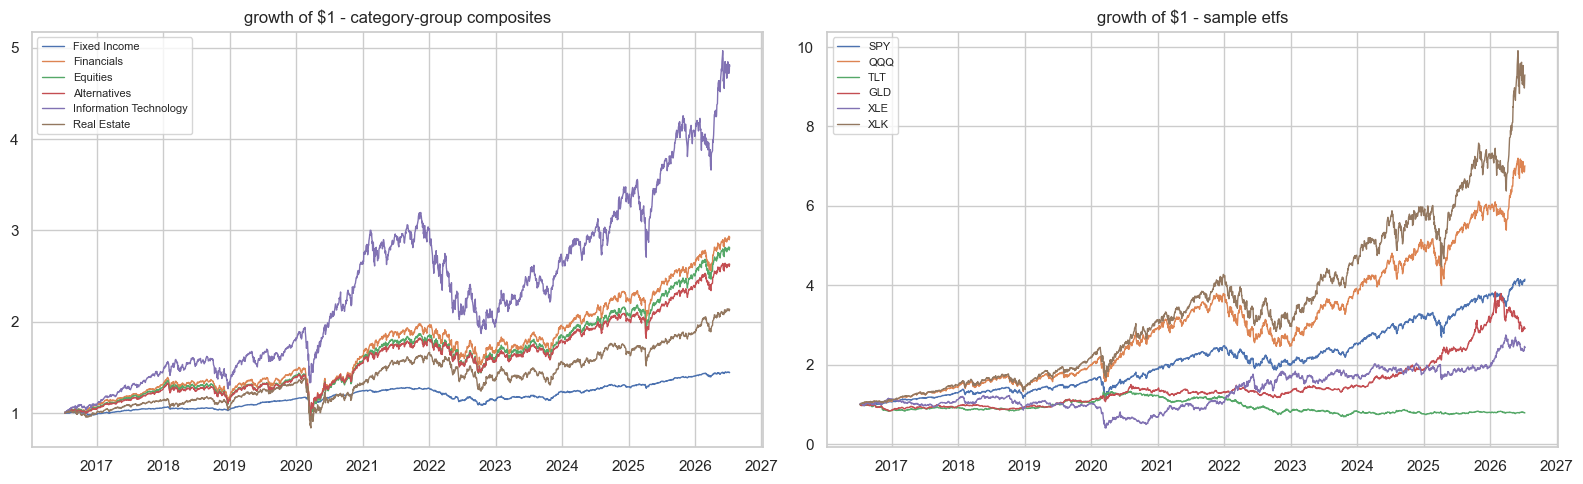

In [7]:
ret = prices.pct_change(fill_method=None)
grp_all = metadata['category_group'].reindex(prices.columns)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
for g in grp_all.value_counts().head(6).index:
    cg = grp_all[grp_all == g].index
    comp = (1 + ret[cg].mean(axis=1).fillna(0)).cumprod()
    ax[0].plot(comp.index, comp.values, lw=1, label=g)
ax[0].set_title('growth of $1 - category-group composites'); ax[0].legend(fontsize=8)
for t in [x for x in ['SPY','QQQ','TLT','GLD','XLE','XLK'] if x in prices.columns]:
    s = prices[t].dropna(); ax[1].plot(s.index, s / s.iloc[0], lw=1, label=t)
ax[1].set_title('growth of $1 - sample etfs'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### return / risk distributions across funds

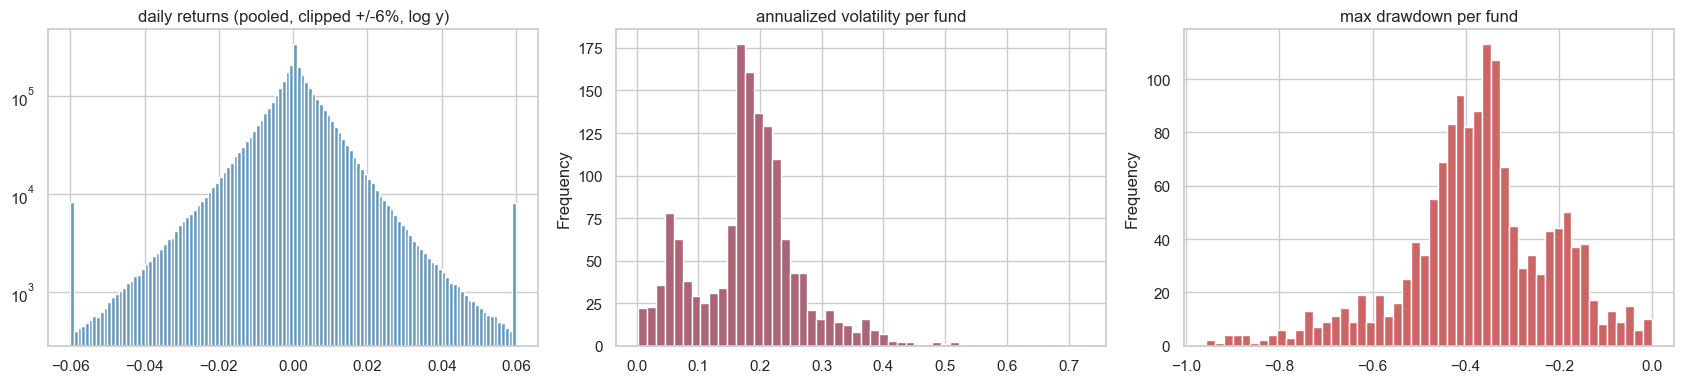

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
dr = ret.values.ravel(); dr = dr[~np.isnan(dr)]
ax[0].hist(np.clip(dr, -0.06, 0.06), bins=120, color='#69b'); ax[0].set_yscale('log')
ax[0].set_title('daily returns (pooled, clipped +/-6%, log y)')
(ret.std() * np.sqrt(252)).dropna().plot.hist(bins=50, ax=ax[1], color='#a67'); ax[1].set_title('annualized volatility per fund')
(prices / prices.cummax() - 1).min().dropna().plot.hist(bins=50, ax=ax[2], color='#c66'); ax[2].set_title('max drawdown per fund')
plt.tight_layout(); plt.show()

### risk vs return by asset class

each fund's annualized return vs its vol, over its own life. tech/sector funds sit high on both,
bonds low on both - the classic risk/return spread.

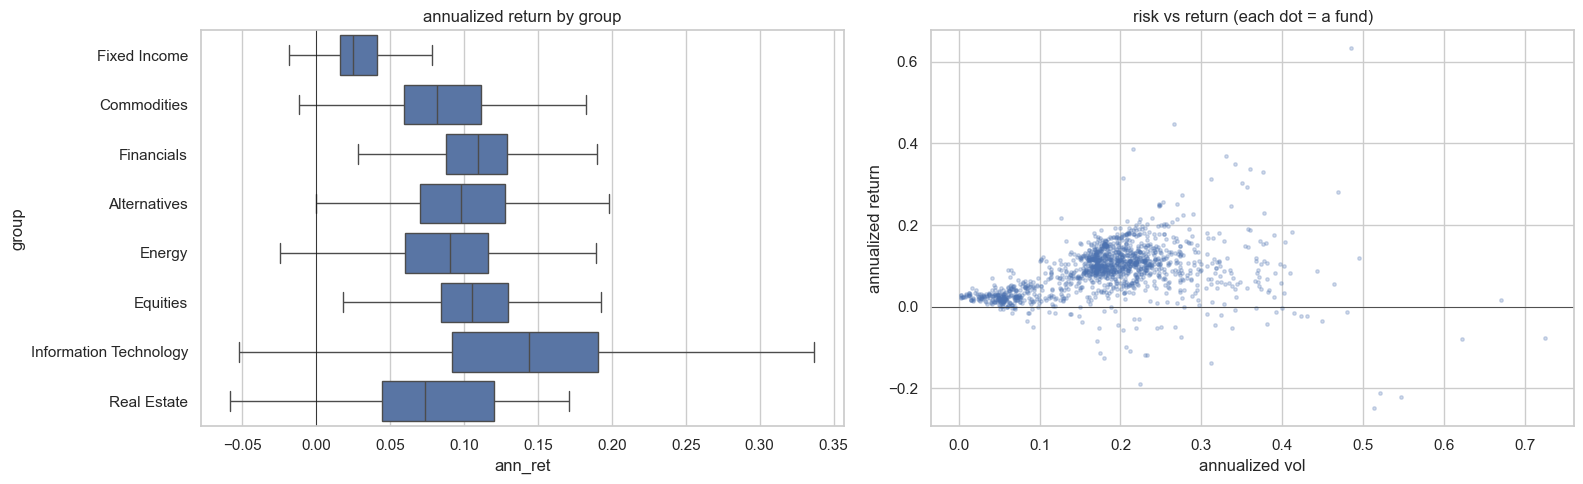

In [9]:
n = prices.notna().sum()
ann_ret = (prices.ffill().iloc[-1] / prices.bfill().iloc[0]) ** (252 / n) - 1
ann_vol = ret.std() * np.sqrt(252)
rr = pd.DataFrame({'ann_ret': ann_ret, 'ann_vol': ann_vol, 'group': grp_all}).dropna()
rr = rr[(rr['ann_vol'] < 1.5) & (rr['ann_ret'].between(-0.5, 1.5))]      # trim short-history outliers for display
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
big_g = rr['group'].value_counts().head(8).index
sns.boxplot(data=rr[rr['group'].isin(big_g)], y='group', x='ann_ret', ax=ax[0], showfliers=False)
ax[0].set_title('annualized return by group'); ax[0].axvline(0, color='k', lw=.6)
ax[1].scatter(rr['ann_vol'], rr['ann_ret'], s=6, alpha=.25); ax[1].set_title('risk vs return (each dot = a fund)')
ax[1].set_xlabel('annualized vol'); ax[1].set_ylabel('annualized return'); ax[1].axhline(0, color='k', lw=.5)
plt.tight_layout(); plt.show()

## the label

`rel = fund_fwd_5d_return - category_median_fwd_5d_return`, bucketed by +/- threshold.
we only label funds whose category has at least `min_group` members (else the 'median' is meaningless).

In [10]:
lcfg = cfg['labels']; h, thr, min_group = lcfg['horizon'], lcfg['threshold'], lcfg['min_group']
cat = metadata['category'].reindex(prices.columns)

# only keep funds in real categories big enough to have a meaningful median
counts = cat.value_counts()
big = counts[(counts >= min_group) & (counts.index != 'Uncategorized')].index
cols = cat[cat.isin(big)].index
px = prices[cols]; cat = cat[cols]

fwd = px.shift(-h) / px - 1.0                              # forward h-day return
cat_med = fwd.T.groupby(cat).transform('median').T         # category median, broadcast to members
rel = fwd - cat_med

label = pd.DataFrame(np.where(rel > thr, 'Outperform',
                     np.where(rel < -thr, 'Underperform', 'Neutral')),
                     index=rel.index, columns=rel.columns).where(rel.notna())
balance = pd.Series(label.values.ravel()).value_counts()
print(f'labelling {len(cols)} funds in {len(big)} categories | threshold {thr} ({thr*1e4:.0f} bps)')
balance

labelling 1320 funds in 33 categories | threshold 0.005 (50 bps)


Neutral         1583457
Outperform       720429
Underperform     718589
Name: count, dtype: int64

### tune the threshold

spread is way bigger than the old index-fund set, so the threshold needs to be bigger too.
pick one that gives a balance you like:

In [11]:
relf = rel.stack().dropna()
print('rel std:', round(relf.std()*1e4, 1), 'bps | abs median:', round(relf.abs().median()*1e4, 1), 'bps')
rows = []
for t in [0.001, 0.002, 0.003, 0.005, 0.0075, 0.01, 0.02]:
    up = (relf > t).mean()*100; dn = (relf < -t).mean()*100
    rows.append({'threshold_bps': t*1e4, 'Under_%': round(dn,1), 'Neutral_%': round(100-up-dn,1), 'Over_%': round(up,1)})
pd.DataFrame(rows)

rel std: 161.1 bps | abs median: 46.0 bps


,threshold_bps,Under_%,Neutral_%,Over_%
0,10.0,41.2,17.5,41.2
1,20.0,35.4,29.2,35.4
2,30.0,30.7,38.5,30.7
3,50.0,23.8,52.4,23.8
4,75.0,17.8,64.3,17.9
5,100.0,13.7,72.5,13.8
6,200.0,5.7,88.6,5.7


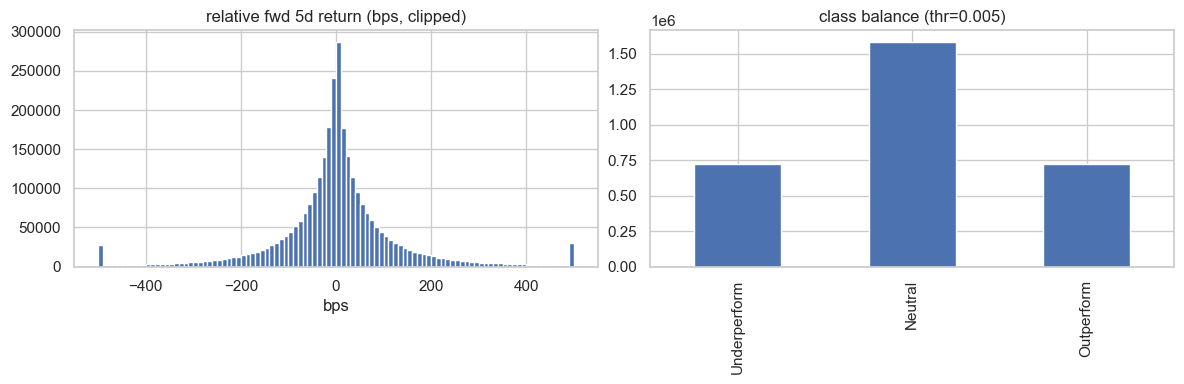

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
(relf.clip(-0.05, 0.05)*1e4).hist(bins=100, ax=ax[0]); ax[0].set_title('relative fwd 5d return (bps, clipped)'); ax[0].set_xlabel('bps')
balance.reindex(['Underperform','Neutral','Outperform']).plot.bar(ax=ax[1]); ax[1].set_title(f'class balance (thr={thr})')
plt.tight_layout(); plt.show()

### dispersion differs a lot by asset class

bond etfs barely move off their peers; sector-equity funds swing hard. so 'beating peers' is a
different-sized bet per group - one global threshold hits each group differently.

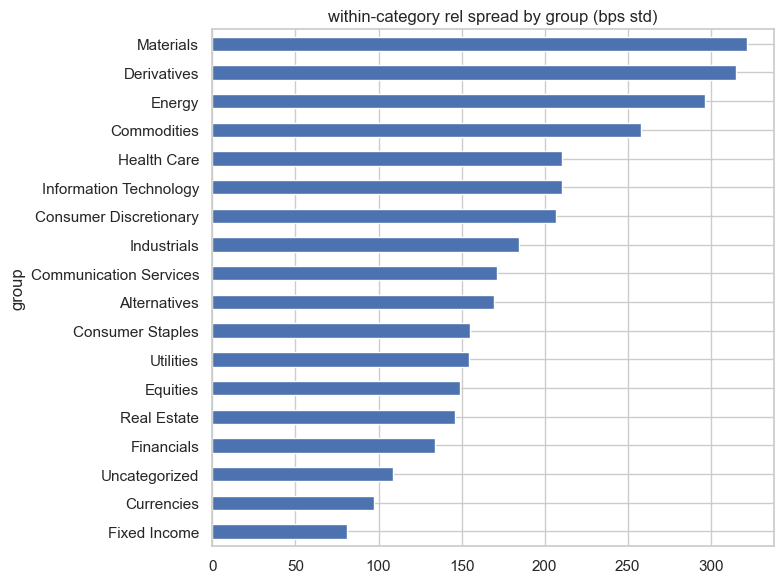

In [13]:
grp = metadata['category_group'].reindex(rel.columns)
disp = rel.stack().rename('rel').reset_index()
disp['group'] = disp['ticker'].map(grp)
by_grp = disp.groupby('group')['rel'].std().mul(1e4).sort_values(ascending=False)
ax = by_grp.plot.barh(figsize=(8, 6)); ax.invert_yaxis(); ax.set_title('within-category rel spread by group (bps std)')
plt.tight_layout(); plt.show()

### ... which means the class balance is per-asset-class

**biggest takeaway of the notebook:** bonds sit on their peer median almost always (~77% neutral),
sector-equity funds diverge constantly (~25% neutral). a model will find 'beat your peers' easy to
call in fixed income and hard in sectors - worth stratifying metrics by group later.

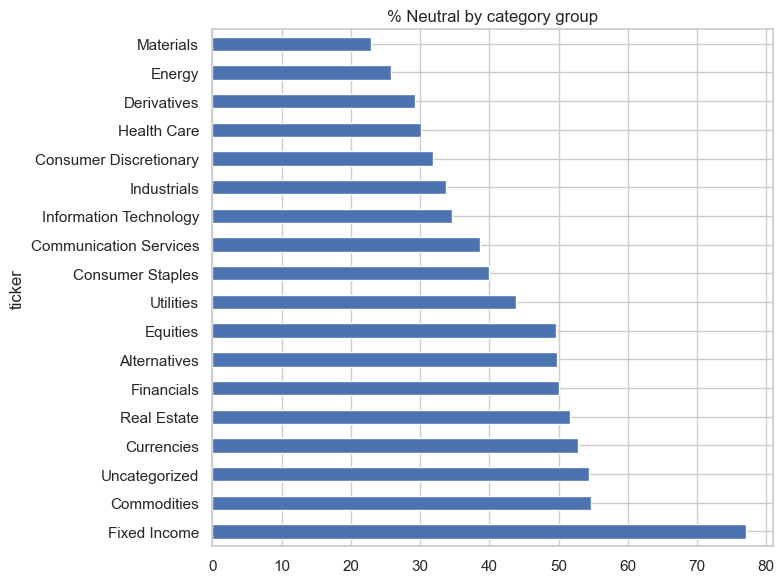

ticker
Materials                 23.0
Energy                    26.0
Derivatives               29.0
Health Care               30.0
Consumer Discretionary    32.0
Industrials               34.0
Information Technology    35.0
Communication Services    39.0
Consumer Staples          40.0
Utilities                 44.0
Equities                  50.0
Alternatives              50.0
Financials                50.0
Real Estate               52.0
Currencies                53.0
Uncategorized             54.0
Commodities               55.0
Fixed Income              77.0
dtype: float64

In [14]:
ll = label.stack(); ll.index.names = ['date', 'ticker']
tick = ll.index.get_level_values('ticker')
neu_by = ll.eq('Neutral').groupby(tick.map(metadata['category_group'])).mean().mul(100).sort_values()
ax = neu_by.plot.barh(figsize=(8, 6)); ax.set_title('% Neutral by category group'); ax.invert_yaxis()
plt.tight_layout(); plt.show()
neu_by.round(0)

### ⚠️ the labels overlap - modeling must use purged/embargoed CV

the label is a *forward 5-day* return measured every day, so two consecutive days share 4 of their 5
future days. that makes the daily label strongly autocorrelated - a random shuffle *or* a plain time
split will leak the future into training and inflate the scores. use purged + embargoed walk-forward
CV (or sample every 5th day). this is the one thing that'll silently break the modeling if ignored.

In [15]:
ac = rel.corrwith(rel.shift(1)).median()
print(f'median lag-1 autocorrelation of daily rel: {ac:.2f}  (~0 = independent days, high = heavy overlap)')

median lag-1 autocorrelation of daily rel: 0.76  (~0 = independent days, high = heavy overlap)


### class balance moves with the market

calm years -> most funds hug their peers (more neutral); volatile years (2020, 2022) -> they scatter
(less neutral). so train and test have to be different time periods, never shuffled.

In [16]:
yr = ll.index.get_level_values('date').year
by_year = pd.DataFrame({'labelled_rows': ll.groupby(yr).size(),
                        'pct_neutral': ll.eq('Neutral').groupby(yr).mean().mul(100).round(0)})
by_year

,labelled_rows,pct_neutral
date,,
2016,109904,55.0
2017,239159,60.0
2018,264836,54.0
2019,285146,60.0
2020,309512,45.0
2021,328904,53.0
2022,329556,46.0
2023,328672,53.0
2024,332058,53.0


### more label views

threshold sweep as a picture, the raw (not-relative) forward return, how rel spreads per group,
and how the class mix shifts year to year.

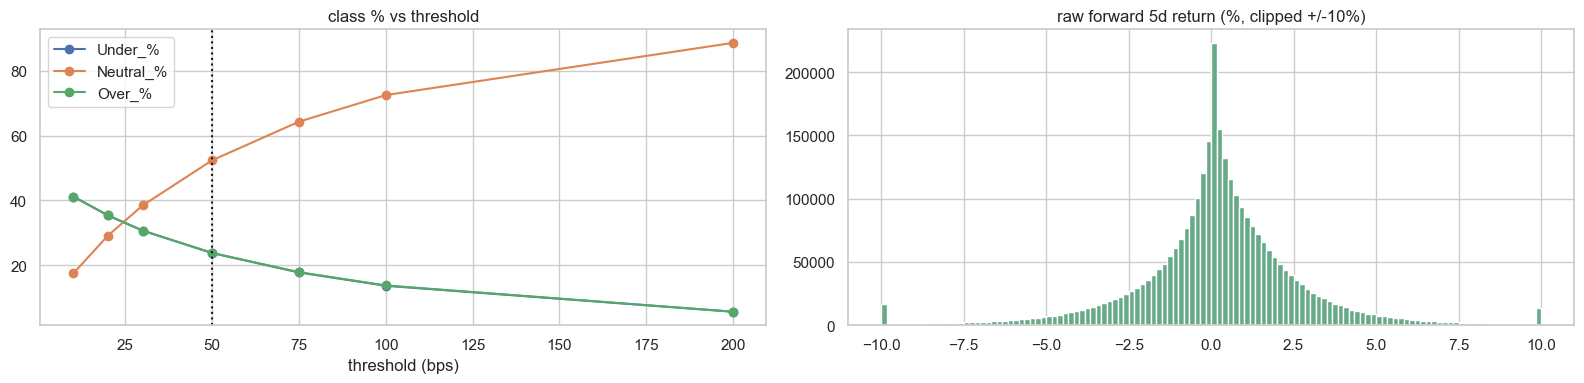

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4))
pd.DataFrame(rows).set_index('threshold_bps').plot(ax=ax[0], marker='o')
ax[0].set_title('class % vs threshold'); ax[0].set_xlabel('threshold (bps)'); ax[0].axvline(thr*1e4, color='k', ls=':')
fr = fwd.stack(future_stack=True).dropna()
ax[1].hist(fr.clip(-0.1, 0.1) * 100, bins=120, color='#6a8'); ax[1].set_title('raw forward 5d return (%, clipped +/-10%)')
plt.tight_layout(); plt.show()

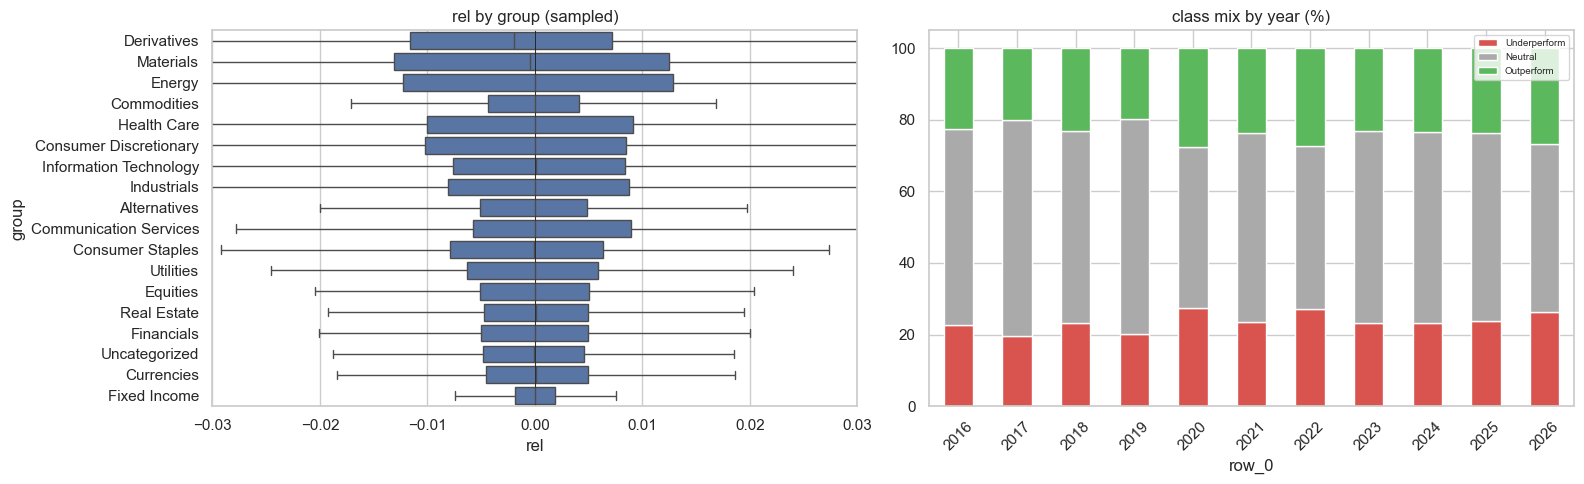

In [18]:
rl = rel.stack().dropna().rename('rel').reset_index()
rl['group'] = rl['ticker'].map(metadata['category_group'])
samp = rl.sample(min(200000, len(rl)), random_state=0)
order_g = samp.groupby('group')['rel'].std().sort_values(ascending=False).index
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=samp, y='group', x='rel', order=order_g, ax=ax[0], showfliers=False)
ax[0].set_xlim(-0.03, 0.03); ax[0].axvline(0, color='k', lw=.6); ax[0].set_title('rel by group (sampled)')
mix = pd.crosstab(ll.index.get_level_values('date').year, ll)
mix = mix.div(mix.sum(axis=1), axis=0).mul(100)[['Underperform','Neutral','Outperform']]
mix.plot.bar(stacked=True, ax=ax[1], color=['#d9534f','#aaaaaa','#5cb85c'])
ax[1].set_title('class mix by year (%)'); ax[1].legend(fontsize=7); ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

## the *real* modeling label — rank-based tercile, delisted included

everything above used the threshold label on the delisted-**excluded** panel — good for building
intuition about threshold sensitivity and dispersion, but not what gets modeled: 04-06 and
`Untitled.ipynb` all independently rebuilt their own label straight from raw prices, ignoring this
notebook's saved `labels.parquet` entirely. the label that actually matters is a **percentile rank of
excess forward return within (date, category), split into exact thirds** — auto-balanced, no
threshold — computed on the delisted-**inclusive** panel (dropping delisted funds using
end-of-panel knowledge is a lookahead, fine for "what does today's universe look like" but not for
anything performance-related). `notebooks/common.py:build_label` implements this, and it's what gets
saved to `labels.parquet` below from here on.

one thing worth checking directly rather than assuming: `04_baseline.ipynb` benchmarks excess return
against the category **mean**, while `05_model`, `06_features_v2`, and `Untitled.ipynb` all use the
category **median** — three-to-one, never reconciled. does that matter? **checked below: no.** the
label is a *rank* of excess return within (date, category), and both mean and median are a single
constant subtracted from every fund in that group that day — subtracting a constant can't change the
*ranking* of a group's values, so the resulting tercile is provably identical either way. standardizing
on median from here on is about consistency and not re-litigating the question later, not a
correctness fix to the discrete label — see the empirical confirmation (and the one place the choice
*does* leave a trace: the size of the raw benchmark gap) right below.

In [19]:
prices_all = pd.read_parquet(RAW / 'prices.parquet')
prices_all.index.name = 'date'; prices_all.columns.name = 'ticker'
badf = metadata['is_leveraged'].fillna(False) | metadata['bad_ticks'].fillna(False)
prices_all = prices_all.drop(columns=[t for t in metadata.index[badf] if t in prices_all.columns])
cat_all = metadata['category'].reindex(prices_all.columns)
sizes_all = cat_all.value_counts()
keep_cats = sizes_all[(sizes_all >= min_group) & (sizes_all.index != 'Uncategorized')].index
keep_all = cat_all[cat_all.isin(keep_cats)].index
prices_all, cat_all = prices_all[keep_all], cat_all[keep_all]
print('delisted-inclusive panel:', prices_all.shape, '|', len(keep_cats), 'categories  (vs',
      prices.shape[1], 'funds in the delisted-excluded EDA panel above)')

delisted-inclusive panel: (2514, 1579) | 35 categories  (vs 1455 funds in the delisted-excluded EDA panel above)


In [20]:
label_median = common.build_label(prices_all, cat_all, h, min_group, benchmark='median')
label_mean = common.build_label(prices_all, cat_all, h, min_group, benchmark='mean')

both = pd.concat({'median': label_median, 'mean': label_mean}, axis=1).dropna()
disagree = (both['median'] != both['mean']).mean() * 100
print(f'{len(both):,} labeled (date, ticker) rows compared')
print(f'{disagree:.2f}% get a different tercile under a mean- vs median-benchmark excess return')
print('expected: exactly 0% -- rank within a (date, category) group is invariant to subtracting a')
print('constant (the benchmark) from every member of that group, so mean vs median never could have')
print('changed the discrete label. confirmed empirically, not just asserted.')
print()
print('confusion between the two labelings (fractions of all labeled rows):')
pd.crosstab(both['median'], both['mean'], normalize=True).mul(100).round(1)

3,357,600 labeled (date, ticker) rows compared
0.00% get a different tercile under a mean- vs median-benchmark excess return
expected: exactly 0% -- rank within a (date, category) group is invariant to subtracting a
constant (the benchmark) from every member of that group, so mean vs median never could have
changed the discrete label. confirmed empirically, not just asserted.

confusion between the two labelings (fractions of all labeled rows):


mean,0.0,1.0,2.0
median,,,
0.0,32.6,0.0,0.0
1.0,0.0,33.3,0.0
2.0,0.0,0.0,34.1


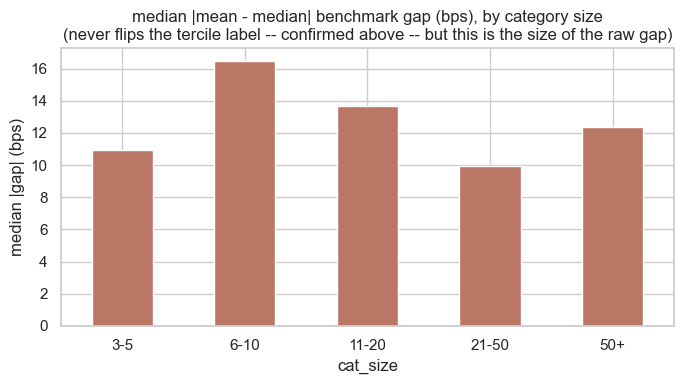

the raw mean/median benchmark gap is not bigger in thin categories, as expected -- but even
there it never changes which tercile a fund lands in (see the confirmation above).


In [21]:
cat_size_by_ticker = cat_all.map(cat_all.value_counts())  # per-ticker: overall size of its category
fwd_all = prices_all.shift(-h) / prices_all - 1.0
bench_mean = fwd_all.T.groupby(cat_all).transform('mean').T
bench_median = fwd_all.T.groupby(cat_all).transform('median').T
gap = (bench_mean - bench_median).abs().stack().rename('gap').reset_index()
gap.columns = ['date', 'ticker', 'gap']
gap['cat_size'] = gap['ticker'].map(cat_size_by_ticker)
size_bins = pd.cut(gap['cat_size'], [0, 5, 10, 20, 50, 10_000],
                    labels=['3-5', '6-10', '11-20', '21-50', '50+'])
by_size = (gap['gap'] * 1e4).groupby(size_bins, observed=True).median()

ax = by_size.plot.bar(figsize=(7, 4), color='#b76')
ax.set_title('median |mean - median| benchmark gap (bps), by category size\n'
              '(never flips the tercile label -- confirmed above -- but this is the size of the raw gap)')
ax.set_ylabel('median |gap| (bps)'); ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()
bigger = 'bigger' if by_size.iloc[0] > by_size.iloc[-1] else 'not bigger'
print(f'the raw mean/median benchmark gap is {bigger} in thin categories, as expected -- but even')
print('there it never changes which tercile a fund lands in (see the confirmation above).')

### how close to the boundary is a typical label? (and does a thin category make it meaningless?)

`Untitled.ipynb` tried this (its cell 29) but computed quantiles on `ret_20d_skip5` — a *feature* —
instead of the actual excess-return variable the label buckets on, so its result didn't mean what it
looked like it meant. redone correctly here: distance from each row's excess return to its own
(date, category) tercile cutoff, in rank space (0..1, so it's comparable across categories of
different sizes) — and whether categories near the `min_group` floor (a 3-fund category's median is
literally one specific fund's return) produce labels that are still informative, or closer to
arbitrary.

C:\Windows\Temp\ipykernel_46972\4258546797.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exl['dist_to_cutoff'] = np.minimum((exl['pct'] - 1 / 3).abs(), (exl['pct'] - 2 / 3).abs())


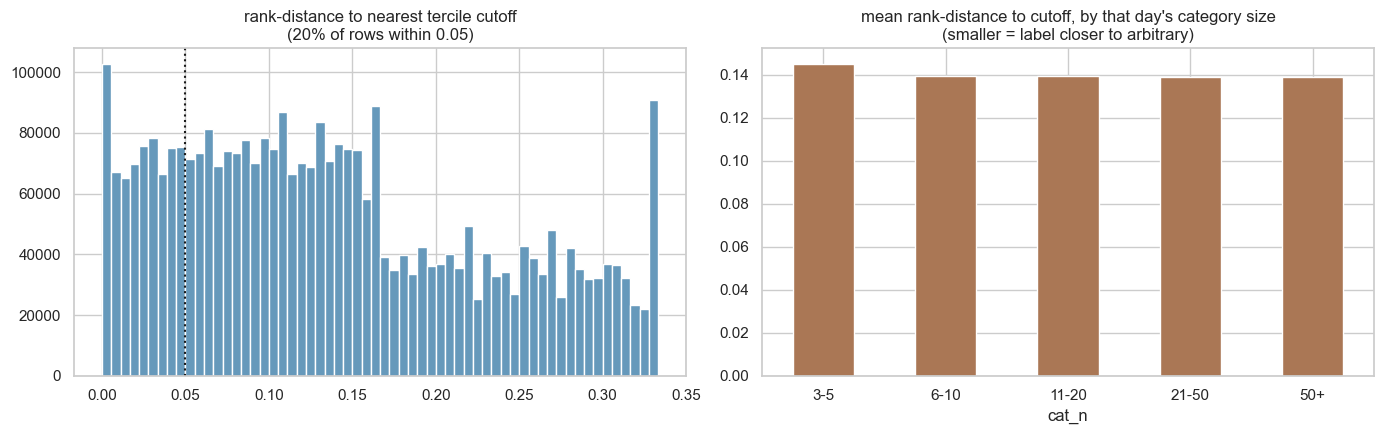

20.1% of labeled rows sit within 0.05 rank-distance of a tercile boundary
category-size floor is min_group = 3 -- rows there are the noisiest labels in the panel


In [22]:
ex = prices_all.shift(-h) / prices_all - 1.0
excess_med = ex - ex.T.groupby(cat_all).transform('median').T
exl = excess_med.stack().rename('excess').reset_index()
exl.columns = ['date', 'ticker', 'excess']
exl['cat'] = exl['ticker'].map(cat_all)
g = exl.groupby(['date', 'cat'])['excess']
exl['pct'] = g.rank(pct=True)
exl['cat_n'] = g.transform('size')
exl = exl[exl['cat_n'] >= min_group]

# distance (in rank space) to the nearer of the two tercile cutoffs
exl['dist_to_cutoff'] = np.minimum((exl['pct'] - 1 / 3).abs(), (exl['pct'] - 2 / 3).abs())

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
exl['dist_to_cutoff'].hist(bins=60, ax=ax[0], color='#69b')
frac_close = (exl['dist_to_cutoff'] < 0.05).mean() * 100
ax[0].axvline(0.05, color='k', ls=':')
ax[0].set_title(f'rank-distance to nearest tercile cutoff\n({frac_close:.0f}% of rows within 0.05)')

size_bins2 = pd.cut(exl['cat_n'], [min_group - 1, 5, 10, 20, 50, 10_000],
                     labels=['3-5', '6-10', '11-20', '21-50', '50+'])
exl.groupby(size_bins2, observed=True)['dist_to_cutoff'].mean().plot.bar(ax=ax[1], color='#a75')
ax[1].set_title("mean rank-distance to cutoff, by that day's category size\n(smaller = label closer to arbitrary)")
ax[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

print(f'{frac_close:.1f}% of labeled rows sit within 0.05 rank-distance of a tercile boundary')
print(f'category-size floor is min_group = {min_group} -- rows there are the noisiest labels in the panel')

## volume (new: `market_data.parquet` from notebook 01)

prices alone say nothing about trading interest. quick look at volume / dollar-volume before they
become features in notebook 03 (`rel_volume_20d`, `cs_rank_dollar_vol`, `vol_zscore`).

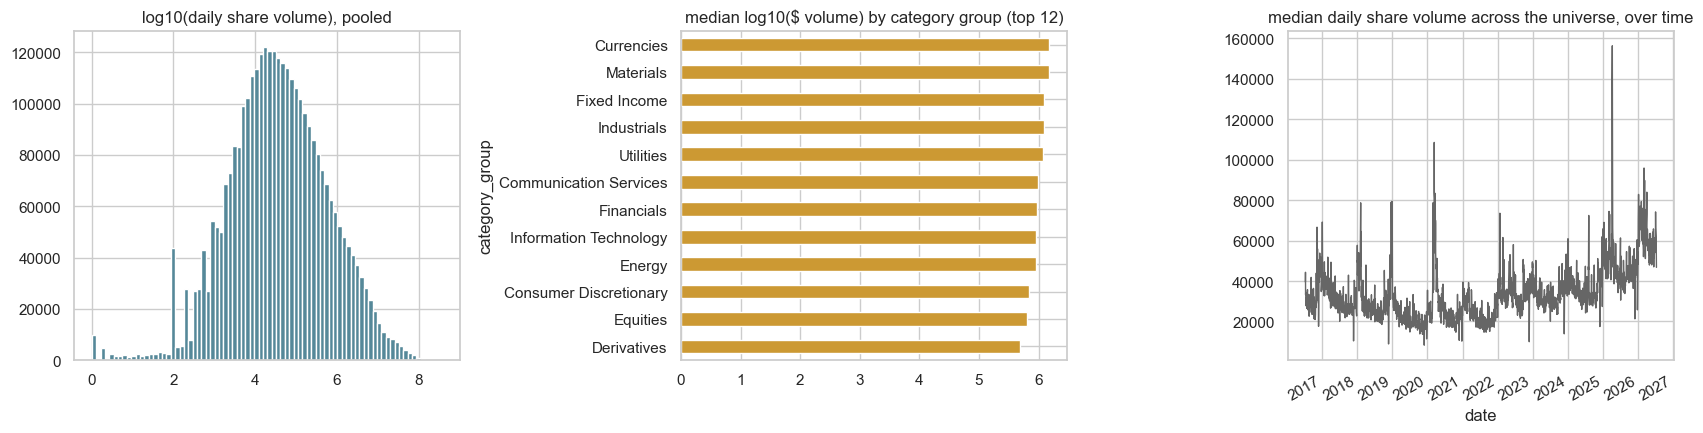

funds with any volume data: 1579 / 1579


In [23]:
market_data = pd.read_parquet(RAW / 'market_data.parquet')
volume = market_data.xs('Volume', axis=1, level=0)
volume.index.name = 'date'; volume.columns.name = 'ticker'
volume = volume.reindex(columns=prices_all.columns)
dollar_vol = prices_all * volume

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
np.log10(volume.replace(0, np.nan)).stack().dropna().hist(bins=80, ax=ax[0], color='#589')
ax[0].set_title('log10(daily share volume), pooled')

med_dv = dollar_vol.median()
grp_dv = metadata['category_group'].reindex(cat_all.index)
by_grp_dv = np.log10(med_dv.replace(0, np.nan)).groupby(grp_dv).median().sort_values()
by_grp_dv.tail(12).plot.barh(ax=ax[1], color='#c93')
ax[1].set_title('median log10($ volume) by category group (top 12)')

vol_trend = volume.median(axis=1)
vol_trend.plot(ax=ax[2], color='#666', lw=1)
ax[2].set_title('median daily share volume across the universe, over time')
plt.tight_layout(); plt.show()
print('funds with any volume data:', volume.notna().any().sum(), '/', volume.shape[1])

## save the real label

`labels.parquet` from here on is the rank-based tercile (median benchmark), on the
delisted-**inclusive** panel — the label notebooks 03/04 actually train against. the threshold-based,
delisted-excluded view earlier in this notebook stays for exploring class-balance / dispersion
intuition, but it was never what got modeled: 04-06 and `Untitled.ipynb` always rebuilt their own
label from scratch and ignored the old `labels.parquet` entirely.

In [24]:
labels_long = label_median.rename('label').to_frame()
labels_long['rel'] = (fwd_all - bench_median).stack()
labels_long['category'] = labels_long.index.get_level_values('ticker').map(cat_all)
labels_long = labels_long.dropna(subset=['label'])
labels_long['label'] = labels_long['label'].astype(int)
PROC = ROOT / cfg['paths']['processed']; PROC.mkdir(parents=True, exist_ok=True)
labels_long.to_parquet(PROC / 'labels.parquet')
print('saved', labels_long.shape, '->', PROC / 'labels.parquet')
print('label balance:', labels_long['label'].value_counts(normalize=True).round(3).to_dict(), '(0=under, 1=neutral, 2=over)')
labels_long.head()

saved (3357600, 3) -> C:\Users\user\Desktop\CS\overp\outperforming\data\processed\labels.parquet
label balance: {2: 0.341, 1: 0.333, 0: 0.326} (0=under, 1=neutral, 2=over)


label       rel          category
date       ticker                                   
2016-07-11 AADR        2  0.006587  Emerging Markets
           AAXJ        1  0.001997  Emerging Markets
           ACWF        2  0.027427             Blend
           ACWI        2  0.001748             Blend
           ACWX        2  0.006876             Blend

### `labels.parquet` is now the real modeling label

delisted funds included (no survivorship bias), category benchmark is the median (matches 05/06/
`Untitled.ipynb`, fixes `04_baseline`'s mean-benchmark bug), rank-based tercile (auto-balanced ~1/3
each). safe to use for anything performance-related — notebooks 03/04 read this file directly
instead of each rebuilding their own copy.